1. Build it step by step
    - Embed target tokens and add positional encodings.
    - Apply masked self-attention to the decoder input.
    - Add residual + normalize.
    - Apply cross-attention with decoder states as queries and encoder states as keys/values.
    - Add residual + normalize again.
    - Apply feed-forward network to each position independently.
    - Add residual + normalize one last time.
    - Stack several decoder blocks, then project to vocabulary logits

2. Why masking matters
    - Without the causal mask, the decoder could “cheat” by looking at future tokens during training. The mask usually uses an upper-triangular pattern that blocks attention to positions ahead in the sequence, preserving the autoregressive setup used at inference time.

3. Cross-attention intuition
    - Cross-attention lets the decoder query the encoder’s output. In practice, the decoder’s hidden states become the queries, while the encoder’s final states provide the keys and values, which lets the decoder pull in source-sequence information relevant to the next target token.

4. Common mistakes
    - Using the same causal mask for cross-attention. Cross-attention should not be causal in the same way as self-attention.
    - Forgetting the right-shifted target input during training. The decoder should learn to predict the next token from previous tokens.
    - Skipping residuals or normalization, which often makes training unstable.

#### Issue with the current model

1. Post-LN: The Original Architecture (What you expected)
    - In the original 2017 "Attention Is All You Need" paper, the sequence of operations was:Attention $\rightarrow$ Add Residual $\rightarrow$ NormalizeExpressed mathematically:$$x = \text{Norm}(x + \text{Layer}(x))$$

    - The Problem: Post-LN makes training highly unstable. The gradients near the final layers tend to explode early in training, meaning you are forced to use a delicate "learning rate warmup" phase just to prevent the model from collapsing.

2. Pre-LN: The Modern Standard (What your code does)
    - To fix the instability of Post-LN, researchers realized they could move the Layer Normalization inside the residual block, right before the attention mechanism. This is called Pre-LN.Normalize $\rightarrow$ Attention $\rightarrow$ Add ResidualExpressed mathematically:$$x = x + \text{Layer}(\text{Norm}(x))$$
    - The Benefit: Notice how the residual connection (x = x + ...) is completely untouched by normalization? This provides a clean, unobstructed highway for gradients to flow from the very end of the network all the way back to the first layer. Pre-LN is significantly easier to train.

In [28]:
import torch
import torch.nn as nn
import math
import matplotlib.pyplot as plt

In [22]:
class DecoderBlock(nn.Module):
    def __init__(self, d_model=512, n_heads=8, d_ff=2048, dropout=0.1):
        super().__init__()

        self.self_attn = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=n_heads,
            dropout=dropout,
            batch_first=True
        )

        self.cross_attn = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=n_heads,
            dropout=dropout,
            batch_first=True
        )

        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model)
        )

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, memory, tgt_mask=None,
                tgt_key_padding_mask=None,
                memory_key_padding_mask=None):
        
        x = self.norm1(x)
        attn_output, _ = self.self_attn(
            x, x, x,
            attn_mask=tgt_mask,
            key_padding_mask=tgt_key_padding_mask,
            need_weights=False
        )
        x = x + self.dropout(attn_output)

        x = self.norm2(x)
        attn_output, _ = self.cross_attn(
            x, memory, memory,
            key_padding_mask=memory_key_padding_mask,
            need_weights=False
        )
        x = x + self.dropout(attn_output)

        x = self.norm3(x)
        ffn_output = self.ffn(x)
        x = x + self.dropout(ffn_output)

        return x

In [35]:
class DecoderBlock(nn.Module):
    def __init__(self, d_model=512, n_heads=8, d_ff=2048, dropout=0.1):
        super().__init__()

        self.self_attn = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=n_heads,
            dropout=dropout,
            batch_first=True
        )

        self.cross_attn = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=n_heads,
            dropout=dropout,
            batch_first=True
        )

        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model)
        )

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(
        self,
        x,
        memory,
        tgt_mask=None,
        tgt_key_padding_mask=None,
        memory_key_padding_mask=None,
        return_attn=False
    ):
        x = self.norm1(x)
        if return_attn:
            self_attn_output, self_attn_weights = self.self_attn(
                x, x, x,
                attn_mask=tgt_mask,
                key_padding_mask=tgt_key_padding_mask,
                need_weights=True,
                average_attn_weights=False
            )
        else:
            self_attn_output, _ = self.self_attn(
                x, x, x,
                attn_mask=tgt_mask,
                key_padding_mask=tgt_key_padding_mask,
                need_weights=False
            )
            self_attn_weights = None

        x = x + self.dropout(self_attn_output)

        x = self.norm2(x)

        if return_attn:
            cross_attn_output, cross_attn_weights = self.cross_attn(
                x, memory, memory,
                key_padding_mask=memory_key_padding_mask,
                need_weights=True,
                average_attn_weights=False
            )
        else:
            cross_attn_output, _ = self.cross_attn(
                x, memory, memory,
                key_padding_mask=memory_key_padding_mask,
                need_weights=False
            )
            cross_attn_weights = None

        x = x + self.dropout(cross_attn_output)

        x = self.norm3(x)

        ffn_output = self.ffn(x)
        x = x + self.dropout(ffn_output)

        return x, self_attn_weights, cross_attn_weights

In [36]:
def generate_casual_mask(size):
    mask = torch.triu(torch.ones(size, size), diagonal=1)
    return mask.bool()   # True = masked

In [37]:
class TransformerDecoder(nn.Module):
    def __init__(self, vocab_size, num_layers=6, d_model=512, n_heads=8, d_ff=2048, dropout=0.1, max_len=5000):
        super().__init__()

        self.d_model = d_model
        self.n_heads = n_heads

        self.token_embedding = nn.Embedding(vocab_size, d_model)
        self.pos_embedding = nn.Embedding(max_len, d_model)

        self.layers = nn.ModuleList([
            DecoderBlock(d_model, n_heads, d_ff, dropout) for _ in range(num_layers)
        ])

        self.final_norm = nn.LayerNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size)

    def forward(
        self,
        tgt,
        memory,
        tgt_key_padding_mask=None,
        memory_key_padding_mask=None,
        return_attn=False
    ):
        bsz, seq_len = tgt.size()

        positions = torch.arange(seq_len, device=tgt.device).unsqueeze(0).expand(bsz, seq_len)

        x = self.token_embedding(tgt) * math.sqrt(self.d_model)
        x = x + self.pos_embedding(positions)

        tgt_mask = generate_casual_mask(seq_len).to(tgt.device)

        all_self_attn = []
        all_cross_attn = []

        for layer in self.layers:
            x, self_attn_w, cross_attn_w = layer(
                x,
                memory,
                tgt_mask=tgt_mask,
                tgt_key_padding_mask=tgt_key_padding_mask,
                memory_key_padding_mask=memory_key_padding_mask,
                return_attn=return_attn
            )

            if return_attn:
                all_self_attn.append(self_attn_w)
                all_cross_attn.append(cross_attn_w)

        x = self.final_norm(x)
        logits = self.lm_head(x)

        if return_attn:
            return logits, all_self_attn, all_cross_attn

        return logits

In [38]:
batch_size = 2
tgt_len = 5
src_len = 7
vocab_size = 1000
d_model = 512

tgt = torch.randint(0, vocab_size, (batch_size, tgt_len))
memory = torch.rand(batch_size, src_len, d_model)

model = TransformerDecoder(vocab_size, num_layers=2, d_model=d_model, n_heads=8)

logits, self_attn_list, cross_attn_list = model(tgt, memory, return_attn=True)

print("logits shape:", logits.shape)
print("num layers:", len(self_attn_list))
print("self attention shape of layer 0:", self_attn_list[0].shape)
print("cross attention shape of layer 0:", cross_attn_list[0].shape)

logits shape: torch.Size([2, 5, 1000])
num layers: 2
self attention shape of layer 0: torch.Size([2, 8, 5, 5])
cross attention shape of layer 0: torch.Size([2, 8, 5, 7])


In [39]:
def plot_attention_head(attn_weights, layer_idx=0, head_idx=0, batch_idx=0, title="Attention"):
    """
    attn_weights: list of tensors, one per layer
    each tensor shape: [batch, heads, q_len, k_len]
    """
    attn = attn_weights[layer_idx][batch_idx, head_idx].detach().cpu()

    plt.figure(figsize=(6, 5))
    plt.imshow(attn, aspect='auto')
    plt.colorbar()
    plt.xlabel("Key positions")
    plt.ylabel("Query positions")
    plt.title(f"{title} | Layer {layer_idx} | Head {head_idx} | Batch {batch_idx}")
    plt.show()

def plot_all_heads(attn_weights, layer_idx=0, batch_idx=0, title_prefix="Attention"):
    """
    attn_weights[layer_idx]: [batch, heads, q_len, k_len]
    """
    layer_attn = attn_weights[layer_idx][batch_idx].detach().cpu()
    num_heads = layer_attn.shape[0]

    fig, axes = plt.subplots(1, num_heads, figsize=(3 * num_heads, 3))

    if num_heads == 1:
        axes = [axes]

    for h in range(num_heads):
        ax = axes[h]
        im = ax.imshow(layer_attn[h], aspect='auto')
        ax.set_title(f"Head {h}")
        ax.set_xlabel("Key")
        ax.set_ylabel("Query")

    fig.suptitle(f"{title_prefix} - Layer {layer_idx}, Batch {batch_idx}")
    plt.tight_layout()
    plt.show()

def plot_attention_with_tokens(attn_weights, tokens_q, tokens_k, layer_idx=0, head_idx=0, batch_idx=0, title="Attention"):
    attn = attn_weights[layer_idx][batch_idx, head_idx].detach().cpu()

    plt.figure(figsize=(7, 6))
    plt.imshow(attn, aspect='auto')
    plt.colorbar()
    plt.xticks(range(len(tokens_k)), tokens_k, rotation=45)
    plt.yticks(range(len(tokens_q)), tokens_q)
    plt.xlabel("Key tokens")
    plt.ylabel("Query tokens")
    plt.title(f"{title} | Layer {layer_idx} | Head {head_idx}")
    plt.tight_layout()
    plt.show()

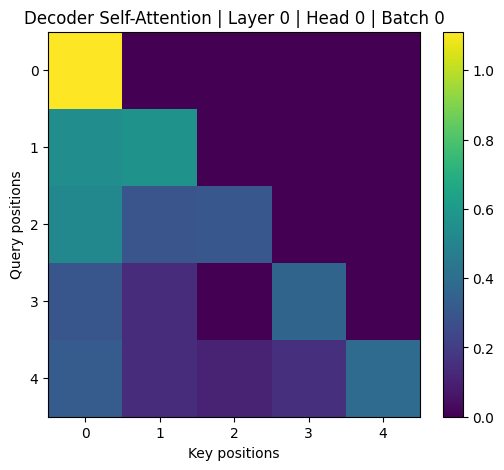

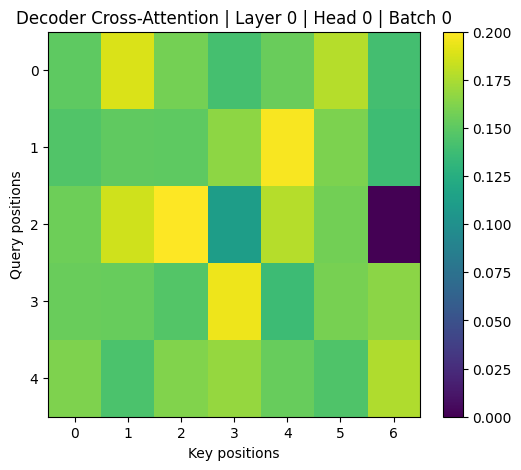

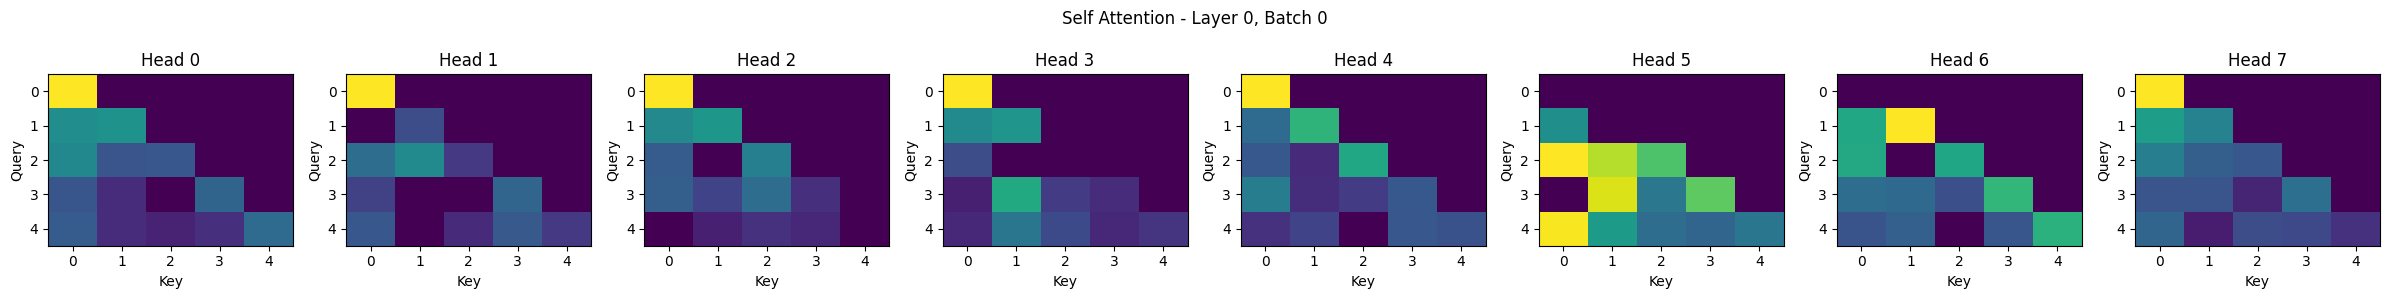

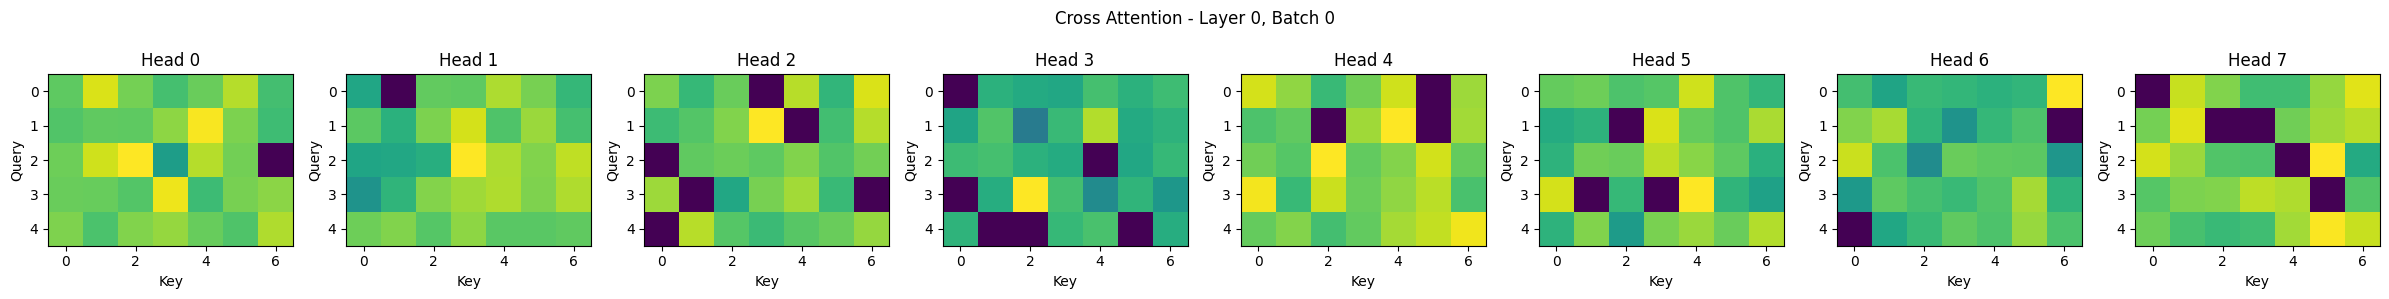

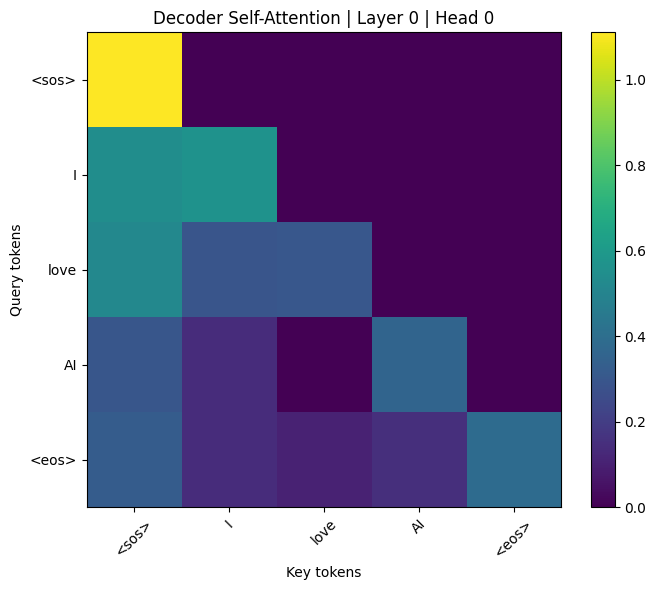

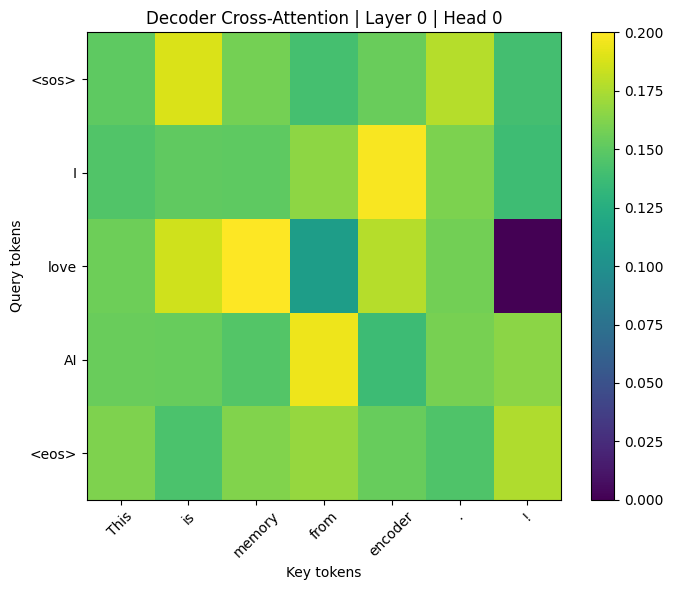

In [40]:
plot_attention_head(self_attn_list, layer_idx=0, head_idx=0, batch_idx=0, title="Decoder Self-Attention")
plot_attention_head(cross_attn_list, layer_idx=0, head_idx=0, batch_idx=0, title="Decoder Cross-Attention")
plot_all_heads(self_attn_list, layer_idx=0, batch_idx=0, title_prefix="Self Attention")
plot_all_heads(cross_attn_list, layer_idx=0, batch_idx=0, title_prefix="Cross Attention")

tokens_tgt = ["<sos>", "I", "love", "AI", "<eos>"]
tokens_src = ["This", "is", "memory", "from", "encoder", ".", "!"]

plot_attention_with_tokens(
    self_attn_list,
    tokens_q=tokens_tgt,
    tokens_k=tokens_tgt,
    layer_idx=0,
    head_idx=0,
    batch_idx=0,
    title="Decoder Self-Attention"
)

plot_attention_with_tokens(
    cross_attn_list,
    tokens_q=tokens_tgt,
    tokens_k=tokens_src,
    layer_idx=0,
    head_idx=0,
    batch_idx=0,
    title="Decoder Cross-Attention"
)

#### Upcoming
1. Training Dynamics: Teacher Forcing
2. The Inference Loop (Autoregressive Generation)
3. Decoding Strategies (How to pick the next word)
    - Greedy Search:
    - Beam Search:
    - Sampling (Temperature, Top-K, Top-p):
4. The Performance Secret: KV Caching